# TP6 — Prédiction de la note d'un hôtel à partir des avis

## Objectif du projet

Dans ce projet, on cherche à prédire la variable **`Reviewer_Score`** à partir des informations disponibles sur les clients, les hôtels et surtout le contenu des avis.

Le travail suit une démarche simple :

1. charger et comprendre les données ;
2. préparer quelques variables ;
3. faire une analyse exploratoire ;
4. transformer les avis textuels avec **TF-IDF** ;
5. construire un premier modèle de régression ;
6. comparer quelques réglages avec une validation croisée ;
7. produire les prédictions finales.

La base de données vient de Kaggle. Lien: https://www.kaggle.com/competitions/prediction-des-notes-des-hotels

## 1. Importation des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

# Lecture des deux fichiers
train = pd.read_csv("train_reviews.csv")
test = pd.read_csv("test_reviews.csv")

print("Dimensions du train :", train.shape)
print("Dimensions du test  :", test.shape)

print("\nColonnes du train :")
print(train.columns.tolist())

Dimensions du train : (361016, 18)
Dimensions du test  : (154722, 17)

Colonnes du train :
['Unnamed: 0', 'Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Tags', 'days_since_review', 'lat', 'lng', 'Reviewer_Score']


## 2. Quel type de problème ?

La variable à prédire est `Reviewer_Score`. Il s'agit d'une **valeur numérique**, et non d'une catégorie.

On traite donc ce problème comme un problème de **régression**.

## 3. Préparation de la date

La colonne `Review_Date` est une date. Pour pouvoir l'utiliser plus facilement, on la transforme en trois informations :

- année ;
- mois ;
- jour de la semaine.

On conserve ensuite uniquement ces informations et on supprime la date brute.

In [2]:
# Conversion en vraie date
train['Review_Date'] = pd.to_datetime(train['Review_Date'])
test['Review_Date'] = pd.to_datetime(test['Review_Date'])

# Extraction de différentes informations à partir de la date
for df in [train, test]:
    df['Review_Year'] = df['Review_Date'].dt.year
    df['Review_Month'] = df['Review_Date'].dt.month
    df['Review_Day_of_Week'] = df['Review_Date'].dt.dayofweek

# Pour les graphiques, on utilise les noms des jours
jours = {
    0: 'Lundi',
    1: 'Mardi',
    2: 'Mercredi',
    3: 'Jeudi',
    4: 'Vendredi',
    5: 'Samedi',
    6: 'Dimanche'
}

for df in [train, test]:
    df['Review_Day_of_Week'] = df['Review_Day_of_Week'].map(jours)

# La date brute n'est plus nécessaire
train = train.drop(columns=['Review_Date'])
test = test.drop(columns=['Review_Date'])

train[['Review_Year', 'Review_Month', 'Review_Day_of_Week']].head()

,Review_Year,Review_Month,Review_Day_of_Week
0,2017,3,Jeudi
1,2016,5,Lundi
2,2017,6,Samedi
3,2016,9,Mercredi
4,2015,8,Dimanche


## 4. Colonnes retirées

Certaines variables sont retirées car je les juge inintéressantes pour les modèles ML

In [3]:
# On garde l'identifiant du fichier de test à part pour l'export final.
id_test = test['Unnamed: 0'].copy()

columns_to_drop = [
    'Unnamed: 0',
    'Hotel_Address',
    'Hotel_Name',
    'Additional_Number_of_Scoring',
    'Total_Number_of_Reviews',
    'Total_Number_of_Reviews_Reviewer_Has_Given'
]

X_train = train.drop(columns=columns_to_drop)
X_test = test.drop(columns=columns_to_drop)

print("Colonnes restantes :")
print(X_train.columns.tolist())

Colonnes restantes :
['Average_Score', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Tags', 'days_since_review', 'lat', 'lng', 'Reviewer_Score', 'Review_Year', 'Review_Month', 'Review_Day_of_Week']


# Analyse exploratoire

L'objectif de cette partie est d'observer les données avant de construire le modèle. Certaines questions sont exploratoires : elles ne cherchent pas à établir une causalité, mais à comprendre la base et à repérer d'éventuelles tendances.

Dans les graphiques ci-dessous, on utilise arbitrairement :

- **bonne review** : `Reviewer_Score >= 8` ;
- **mauvaise review** : `Reviewer_Score <= 5`.

## 5. Quels mots caractérisent les bonnes et les mauvaises reviews ?

On utilise **TF-IDF** pour mesurer l'importance des mots dans les textes.

L'idée est simple : un mot fréquent dans un ensemble de textes mais peu fréquent dans l'ensemble de référence peut obtenir un poids TF-IDF important.

Pour cette première exploration, les textes sont traités séparément:

- `Positive_Review` pour les bonnes reviews ;
- `Negative_Review` pour les mauvaises reviews.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Copie utilisée uniquement pour l'analyse exploratoire
df = X_train.copy()

good_reviews = df.loc[df['Reviewer_Score'] >= 8, 'Positive_Review'].fillna('')
bad_reviews = df.loc[df['Reviewer_Score'] <= 5, 'Negative_Review'].fillna('')

# Quelques mots très génériques pour cette visualisation.
# Ce choix est exploratoire : on pourra le modifier selon ce que l'on observe.
custom_stopwords = ['hotel', 'room', 'rooms', 'stay', 'place']
english_stop_words = list(text.ENGLISH_STOP_WORDS)
all_stop_words = english_stop_words + custom_stopwords

# TF-IDF pour les bonnes reviews
tfidf_good = TfidfVectorizer(
    stop_words=all_stop_words,
    max_features=1000
)
X_good = tfidf_good.fit_transform(good_reviews)
good_words = tfidf_good.get_feature_names_out()
good_scores = X_good.sum(axis=0).A1

# TF-IDF pour les mauvaises reviews
tfidf_bad = TfidfVectorizer(
    stop_words=all_stop_words,
    max_features=1000
)
X_bad = tfidf_bad.fit_transform(bad_reviews)
bad_words = tfidf_bad.get_feature_names_out()
bad_scores = X_bad.sum(axis=0).A1

# Mise en tableau des résultats
good_df = pd.DataFrame({'mot': good_words, 'score': good_scores})
bad_df = pd.DataFrame({'mot': bad_words, 'score': bad_scores})

# On cherche des mots qui apparaissent uniquement dans un des deux ensembles.
exclusive_good = (
    good_df[~good_df['mot'].isin(bad_words)]
    .sort_values('score', ascending=False)
    .head(15)
)

exclusive_bad = (
    bad_df[~bad_df['mot'].isin(good_words)]
    .sort_values('score', ascending=False)
    .head(15)
)

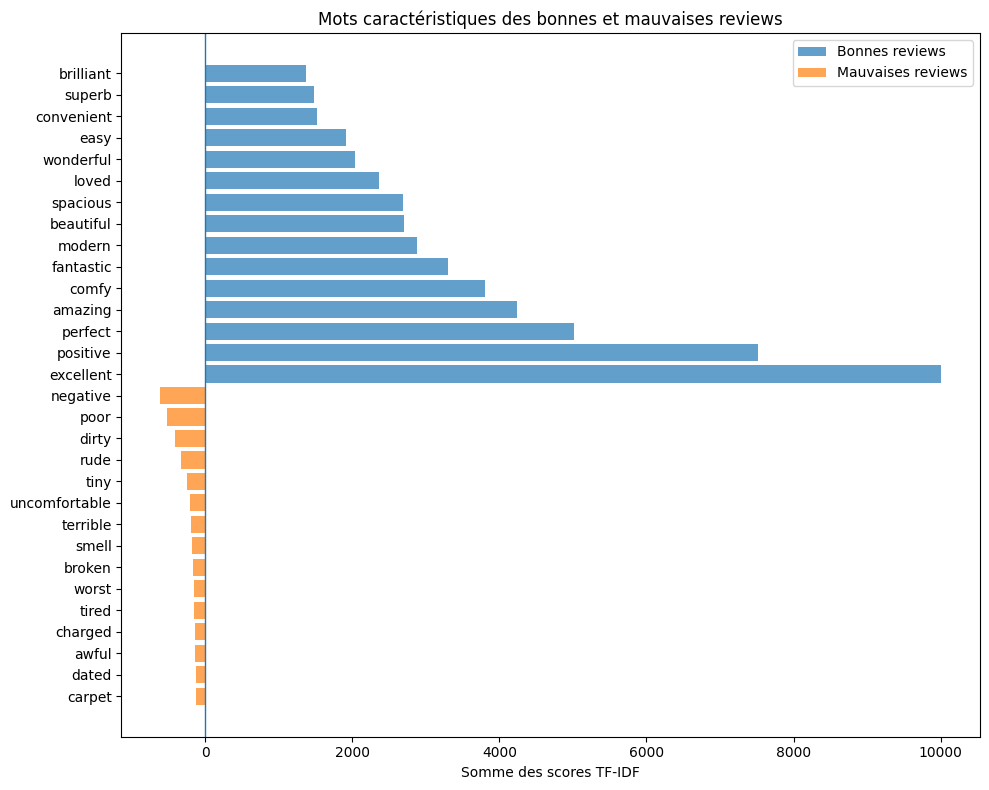

In [5]:
# Visualisation des mots les plus discriminants
plt.figure(figsize=(10, 8))

y_good = np.arange(len(exclusive_good))
y_bad = np.arange(len(exclusive_bad))

plt.barh(
    y_good,
    exclusive_good['score'],
    alpha=0.7,
    label='Bonnes reviews'
)

plt.barh(
    -y_bad - 1,
    -exclusive_bad['score'],
    alpha=0.7,
    label='Mauvaises reviews'
)

plt.yticks(
    list(y_good) + list(-y_bad - 1),
    list(exclusive_good['mot']) + list(exclusive_bad['mot'])
)

plt.xlabel('Somme des scores TF-IDF')
plt.title('Mots caractéristiques des bonnes et mauvaises reviews')
plt.axvline(0, linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Quel jour de la semaine fait-on le plus de reviews ?

On compare :

- le nombre total de reviews ;
- le nombre de bonnes reviews ;
- le nombre de mauvaises reviews.

Cette analyse permet surtout de voir si le jour de la semaine semble être une variable intéressante à conserver.

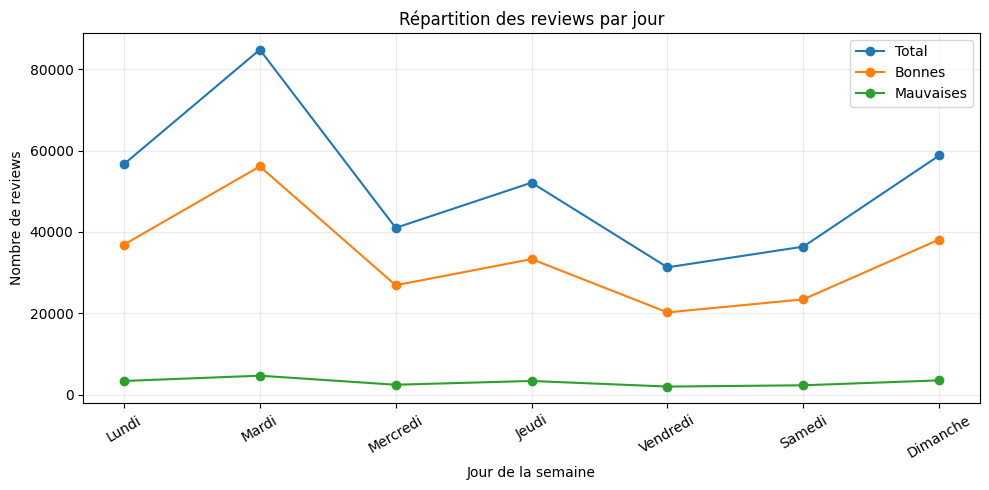

In [6]:
df = X_train.copy()

df['is_good'] = df['Reviewer_Score'] >= 8
df['is_bad'] = df['Reviewer_Score'] <= 5

ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

total_per_day = df['Review_Day_of_Week'].value_counts().reindex(ordre_jours, fill_value=0)
good_per_day = df.loc[df['is_good'], 'Review_Day_of_Week'].value_counts().reindex(ordre_jours, fill_value=0)
bad_per_day = df.loc[df['is_bad'], 'Review_Day_of_Week'].value_counts().reindex(ordre_jours, fill_value=0)

plt.figure(figsize=(10, 5))
plt.plot(ordre_jours, total_per_day.values, marker='o', label='Total')
plt.plot(ordre_jours, good_per_day.values, marker='o', label='Bonnes')
plt.plot(ordre_jours, bad_per_day.values, marker='o', label='Mauvaises')
plt.xlabel('Jour de la semaine')
plt.ylabel('Nombre de reviews')
plt.title('Répartition des reviews par jour')
plt.xticks(rotation=30)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Les notes semblent-elles varier selon l'année ?

On reprend la même logique pour l'année. 

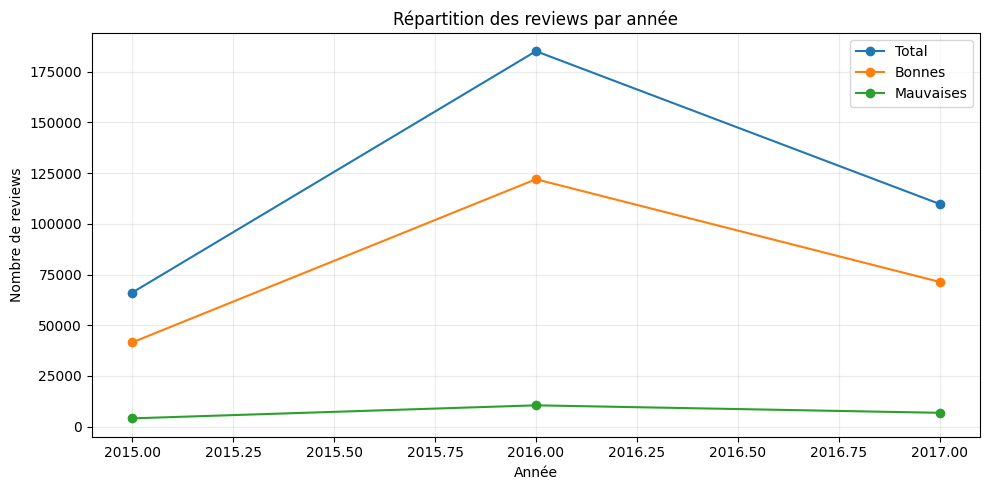

In [7]:
df = X_train.copy()

df['is_good'] = df['Reviewer_Score'] >= 8
df['is_bad'] = df['Reviewer_Score'] <= 5

total_per_year = df['Review_Year'].value_counts().sort_index()
good_per_year = df.loc[df['is_good'], 'Review_Year'].value_counts().sort_index()
bad_per_year = df.loc[df['is_bad'], 'Review_Year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(total_per_year.index, total_per_year.values, marker='o', label='Total')
plt.plot(good_per_year.index, good_per_year.values, marker='o', label='Bonnes')
plt.plot(bad_per_year.index, bad_per_year.values, marker='o', label='Mauvaises')
plt.xlabel('Année')
plt.ylabel('Nombre de reviews')
plt.title('Répartition des reviews par année')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 8. La nationalité semble-t-elle liée aux avis ?

On regarde ici la proportion de bonnes et de mauvaises reviews parmi les nationalités les plus représentées dans la base.

On limitera le graphique aux 15 nationalités les plus fréquentes.

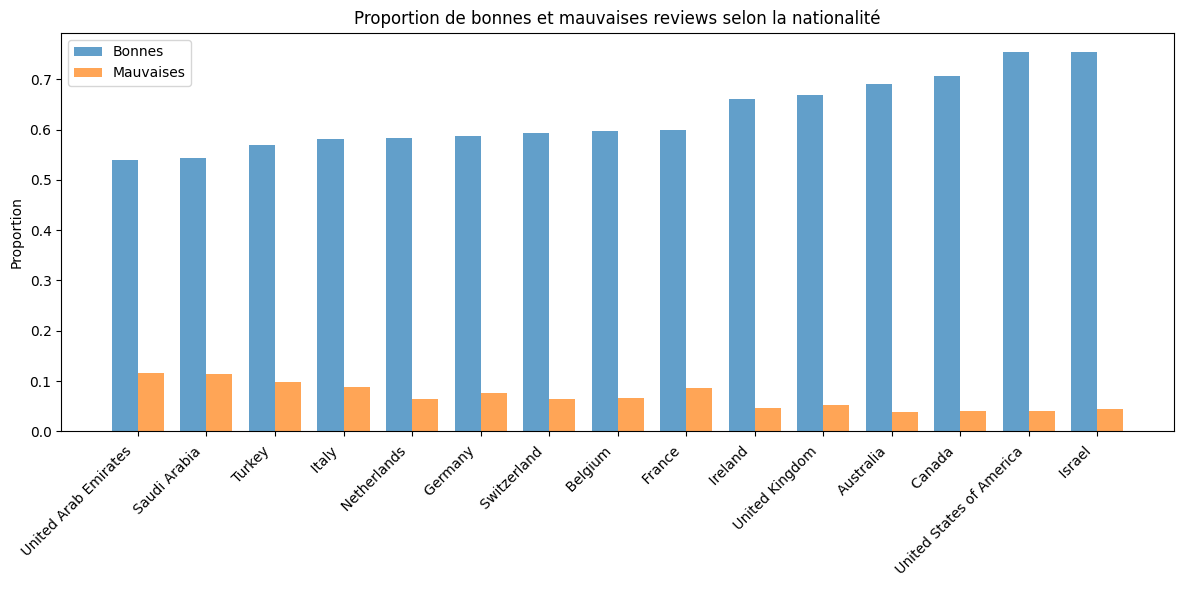

In [8]:
df = X_train.copy()

df['is_good'] = df['Reviewer_Score'] >= 8
df['is_bad'] = df['Reviewer_Score'] <= 5

total_per_nat = df['Reviewer_Nationality'].value_counts()
good_per_nat = df.loc[df['is_good'], 'Reviewer_Nationality'].value_counts()
bad_per_nat = df.loc[df['is_bad'], 'Reviewer_Nationality'].value_counts()

prop_good = (good_per_nat / total_per_nat).fillna(0)
prop_bad = (bad_per_nat / total_per_nat).fillna(0)

top_nats = total_per_nat.head(15).index

prop_good_top = prop_good.loc[top_nats].sort_values()
prop_bad_top = prop_bad.loc[top_nats].loc[prop_good_top.index]

plt.figure(figsize=(12, 6))
x = np.arange(len(top_nats))
largeur = 0.38

plt.bar(x - largeur/2, prop_good_top.values, width=largeur, alpha=0.7, label='Bonnes')
plt.bar(x + largeur/2, prop_bad_top.values, width=largeur, alpha=0.7, label='Mauvaises')

plt.xticks(x, prop_good_top.index, rotation=45, ha='right')
plt.ylabel('Proportion')
plt.title('Proportion de bonnes et mauvaises reviews selon la nationalité')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Les reviews positives sont-elles plus longues ?

On compare la longueur des deux colonnes de texte : `Positive_Review` et `Negative_Review`.

On regarde à la fois la **moyenne** et la **médiane**, car quelques reviews très longues peuvent influencer la moyenne.

In [9]:
df = X_train.copy()

df['positive_length'] = df['Positive_Review'].fillna('').str.split().str.len()
df['negative_length'] = df['Negative_Review'].fillna('').str.split().str.len()

print("Moyenne longueur positives :", df['positive_length'].mean())
print("Moyenne longueur négatives :", df['negative_length'].mean())
print("Médiane longueur positives :", df['positive_length'].median())
print("Médiane longueur négatives :", df['negative_length'].median())

Moyenne longueur positives : 16.465259157488866
Moyenne longueur négatives : 17.8656042945465
Médiane longueur positives : 10.0
Médiane longueur négatives : 7.0


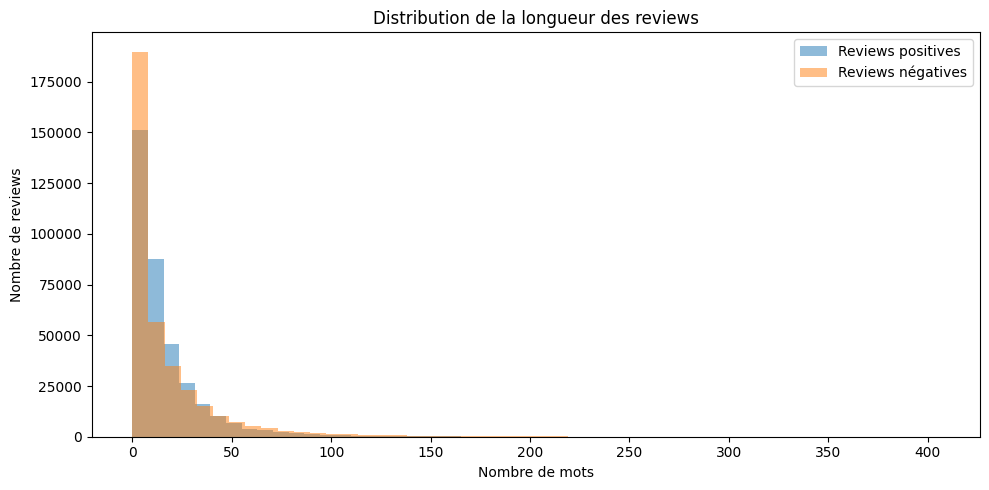

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df['positive_length'], bins=50, alpha=0.5, label='Reviews positives')
plt.hist(df['negative_length'], bins=50, alpha=0.5, label='Reviews négatives')
plt.xlabel('Nombre de mots')
plt.ylabel('Nombre de reviews')
plt.title('Distribution de la longueur des reviews')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Le nombre de reviews données par un utilisateur semble-t-il influencer la note ?

On commence par une corrélation simple, puis on regarde la moyenne des notes par groupes de taille comparable (déciles).


In [11]:
correlation = train[
    'Total_Number_of_Reviews_Reviewer_Has_Given'
].corr(train['Reviewer_Score'])

print("Corrélation :", correlation)

Corrélation : 0.0024226891080170385


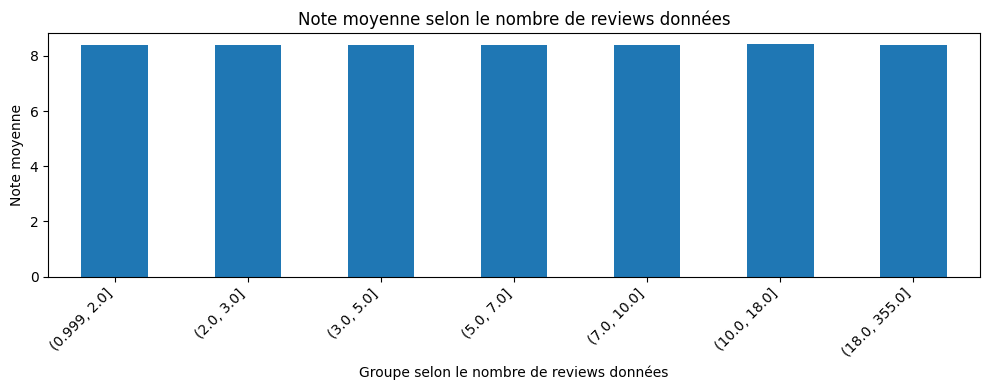

In [12]:
df = train.copy()

df['groupe_reviews'] = pd.qcut(
    df['Total_Number_of_Reviews_Reviewer_Has_Given'],
    q=10,
    duplicates='drop'
)

moyennes = df.groupby('groupe_reviews', observed=True)['Reviewer_Score'].mean()

moyennes.plot(kind='bar', figsize=(10, 4))
plt.xlabel('Groupe selon le nombre de reviews données')
plt.ylabel('Note moyenne')
plt.title('Note moyenne selon le nombre de reviews données')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Complément : regarder les bigrammes

Un **bigramme** est un groupe de deux mots successifs, par exemple `great location` ou `bad service`.

Cette représentation peut faire ressortir des expressions plus informatives qu'un mot pris isolément.

In [13]:
# On reprend la même analyse TF-IDF, mais avec des groupes de deux mots.

good_reviews = X_train.loc[X_train['Reviewer_Score'] >= 8, 'Positive_Review'].fillna('')
bad_reviews = X_train.loc[X_train['Reviewer_Score'] <= 5, 'Negative_Review'].fillna('')

custom_stopwords = ['hotel', 'room', 'rooms', 'stay', 'place']
english_stop_words = list(text.ENGLISH_STOP_WORDS)
all_stop_words = english_stop_words + custom_stopwords

tfidf_good = TfidfVectorizer(
    stop_words=all_stop_words,
    ngram_range=(2, 2),
    max_features=1000
)
X_good = tfidf_good.fit_transform(good_reviews)
good_terms = tfidf_good.get_feature_names_out()
good_scores = X_good.sum(axis=0).A1

tfidf_bad = TfidfVectorizer(
    stop_words=all_stop_words,
    ngram_range=(2, 2),
    max_features=1000
)
X_bad = tfidf_bad.fit_transform(bad_reviews)
bad_terms = tfidf_bad.get_feature_names_out()
bad_scores = X_bad.sum(axis=0).A1

good_bigrams = pd.DataFrame({'expression': good_terms, 'score': good_scores})
bad_bigrams = pd.DataFrame({'expression': bad_terms, 'score': bad_scores})

exclusive_good = (
    good_bigrams[~good_bigrams['expression'].isin(bad_terms)]
    .sort_values('score', ascending=False)
    .head(15)
)

exclusive_bad = (
    bad_bigrams[~bad_bigrams['expression'].isin(good_terms)]
    .sort_values('score', ascending=False)
    .head(15)
)

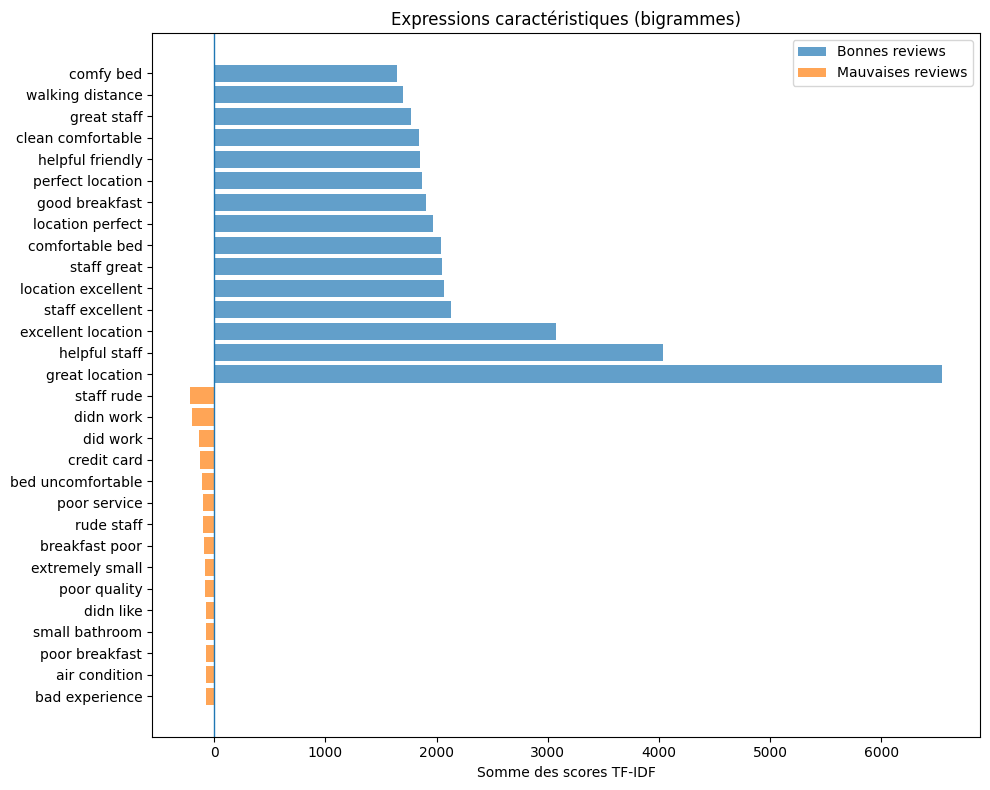

In [14]:
plt.figure(figsize=(10, 8))

y_good = np.arange(len(exclusive_good))
y_bad = np.arange(len(exclusive_bad))

plt.barh(y_good, exclusive_good['score'], alpha=0.7, label='Bonnes reviews')
plt.barh(-y_bad - 1, -exclusive_bad['score'], alpha=0.7, label='Mauvaises reviews')

plt.yticks(
    list(y_good) + list(-y_bad - 1),
    list(exclusive_good['expression']) + list(exclusive_bad['expression'])
)

plt.xlabel('Somme des scores TF-IDF')
plt.title('Expressions caractéristiques (bigrammes)')
plt.axvline(0, linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

# Prédiction

On passe maintenant à la partie de modélisation.

## 11. Construire un modèle de prédiction

L'idée est de combiner plusieurs types d'information :

- le texte des reviews, transformé avec **TF-IDF** ;
- quelques variables numériques ;
- quelques variables catégorielles, encodées avec **OneHotEncoder**.

Le modèle utilisé ici est **LinearSVR**, un modèle de régression linéaire basé sur les Support Vector Machines.

On utilise une **validation croisée** avec `GridSearchCV` pour comparer plusieurs valeurs des paramètres `C` et `epsilon`.

In [16]:
import re
import string
import nltk

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

# Les données sont préparées à partir de la copie déjà nettoyée.
X_train_modele = train.drop(columns=columns_to_drop).copy()
X_test_modele = test.drop(columns=columns_to_drop).copy()

# La cible est retirée des variables explicatives.
y_train = X_train_modele['Reviewer_Score'].copy()
X_train_modele = X_train_modele.drop(columns=['Reviewer_Score'])

# La variable 'days_since_review' est stockée sous forme de texte dans certaines versions du jeu de données.
# On conserve uniquement le nombre de jours.
for df in [X_train_modele, X_test_modele]:
    df['days_since_review'] = (
        df['days_since_review']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype(float)
    )

## 12. Nettoyage du texte

On souhaite enlever quelques éléments peu utiles pour la représentation TF-IDF :

- balises HTML ;
- URL ;
- ponctuation ;
- nombres ;
- mots vides anglais ;
- mots très courts.

Le nettoyage est intégré à un transformer afin de pouvoir l'utiliser directement dans le pipeline scikit-learn.

In [17]:
from nltk.corpus import stopwords

# Télécharger les stopwords anglais si nécessaire.
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))


class NettoyageTexte(BaseEstimator, TransformerMixin):
    """Nettoyage simple d'une colonne de texte avant le TF-IDF."""

    def __init__(self):
        self.stopwords = stop_words

    def _nettoyer_une_phrase(self, texte):
        texte = '' if pd.isna(texte) else str(texte)

        # Retirer les balises HTML et les URL
        texte = re.sub(r'<.*?>', ' ', texte)
        texte = re.sub(r'http\S+', ' ', texte)

        # Mettre tout en minuscules
        texte = texte.lower()

        # Retirer la ponctuation
        texte = texte.translate(str.maketrans('', '', string.punctuation))

        # Retirer les nombres
        texte = re.sub(r'\d+', ' ', texte)

        # Garder les mots qui ne sont pas des stopwords
        mots = [
            mot for mot in texte.split()
            if mot not in self.stopwords and len(mot) > 2
        ]

        return ' '.join(mots)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return pd.Series(X).apply(self._nettoyer_une_phrase)

## 13. Définir les variables du modèle

On garde :

### Variables textuelles
- `Positive_Review`
- `Negative_Review`

### Variables numériques
- `Average_Score`
- nombre de mots positifs ;
- nombre de mots négatifs ;
- `days_since_review` ;
- latitude ;
- longitude.

### Variables catégorielles
- nationalité ;
- tags ;
- année ;
- mois ;
- jour de la semaine.

In [18]:
text_features = ['Positive_Review', 'Negative_Review']

num_features = [
    'Average_Score',
    'Review_Total_Negative_Word_Counts',
    'Review_Total_Positive_Word_Counts',
    'days_since_review',
    'lat',
    'lng'
]

cat_features = [
    'Reviewer_Nationality',
    'Tags',
    'Review_Year',
    'Review_Month',
    'Review_Day_of_Week'
]

## 14. Construire le prétraitement

Chaque type de variable reçoit son traitement :

- **texte** → nettoyage puis TF-IDF ;
- **numérique** → remplacement des valeurs manquantes puis standardisation ;
- **catégoriel** → remplacement des valeurs manquantes puis One-Hot Encoding.

`ColumnTransformer` permet de réunir toutes ces étapes dans un seul pipeline.

In [19]:
preprocesseur = ColumnTransformer(
    transformers=[
        (
            'texte_positif',
            Pipeline([
                ('nettoyage', NettoyageTexte()),
                ('tfidf', TfidfVectorizer(
                    max_features=10000,
                    ngram_range=(1, 2),
                    min_df=5
                ))
            ]),
            'Positive_Review'
        ),
        (
            'texte_negatif',
            Pipeline([
                ('nettoyage', NettoyageTexte()),
                ('tfidf', TfidfVectorizer(
                    max_features=10000,
                    ngram_range=(1, 2),
                    min_df=5
                ))
            ]),
            'Negative_Review'
        ),
        (
            'numerique',
            Pipeline([
                ('imputation', SimpleImputer(strategy='mean')),
                ('standardisation', StandardScaler())
            ]),
            num_features
        ),
        (
            'categoriel',
            Pipeline([
                ('imputation', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            cat_features
        )
    ],
    remainder='drop'
)

## 15. Modèle et validation croisée

Le pipeline final enchaîne :

**prétraitement → LinearSVR**

On fait varier deux paramètres du modèle :

- `C` : contrôle notamment le compromis entre marge et erreurs ;
- `epsilon` : définit une zone autour de la prédiction dans laquelle l'erreur n'est pas pénalisée de la même manière.

La validation croisée permet de comparer ces réglages sans utiliser directement le jeu de test final.

In [20]:
pipeline = Pipeline([
    ('preprocesseur', preprocesseur),
    ('regresseur', LinearSVR(max_iter=2000))
])

parametres = {
    'regresseur__C': [0.5, 1, 5],
    'regresseur__epsilon': [0.1, 0.2]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=parametres,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=2,
    n_jobs=-1
)

## 16. Entraînement

In [21]:
print("Entraînement de GridSearchCV...")
grid.fit(X_train_modele, y_train)

print("Entraînement terminé.")
print("Meilleurs paramètres :", grid.best_params_)

Entraînement de GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Entraînement terminé.
Meilleurs paramètres : {'regresseur__C': 0.5, 'regresseur__epsilon': 0.2}


## 17. Prédictions sur le jeu de test

Une fois les meilleurs paramètres sélectionnés, on utilise le meilleur modèle pour prédire la note de chaque ligne du fichier de test.

On sauvegarde ensuite deux colonnes :

- `ID` : identifiant original ;
- `Predicted_Score` : score prédit.

In [22]:
best_model = grid.best_estimator_

y_pred_test = best_model.predict(X_test_modele)

predictions = pd.DataFrame({
    'ID': id_test,
    'Predicted_Score': y_pred_test
})

predictions.to_csv('predictions_test.csv', index=False)

print("Fichier créé : predictions_test.csv")
predictions.head()

Fichier créé : predictions_test.csv


,ID,Predicted_Score
0,488440,8.699677
1,274649,7.171487
2,374688,8.802343
3,404352,10.391230
4,451596,9.257258


# Bilan

Dans ce projet, j'ai utilisé :

- **pandas** pour manipuler les données ;
- **TF-IDF** pour représenter les avis textuels ;
- **One-Hot Encoding** pour les variables catégorielles ;
- **StandardScaler** pour les variables numériques ;
- **Pipeline / ColumnTransformer** pour organiser le prétraitement ;
- **LinearSVR** pour la régression ;
- **GridSearchCV + validation croisée** pour chercher de bons hyperparamètres.

L'idée importante à retenir est que le modèle ne lit pas directement les phrases : il faut d'abord transformer les textes en variables numériques. TF-IDF fournit cette représentation, puis `LinearSVR` apprend une relation entre ces variables et la note finale.